# Aufgabe 1

Bei Aufgabe 1 war es die Aufgabe die Entladung eines Kondensators im RC Kreis für 5 verschiedene Widerstände zu messen. Die Schaltung sah wie folgt aus:
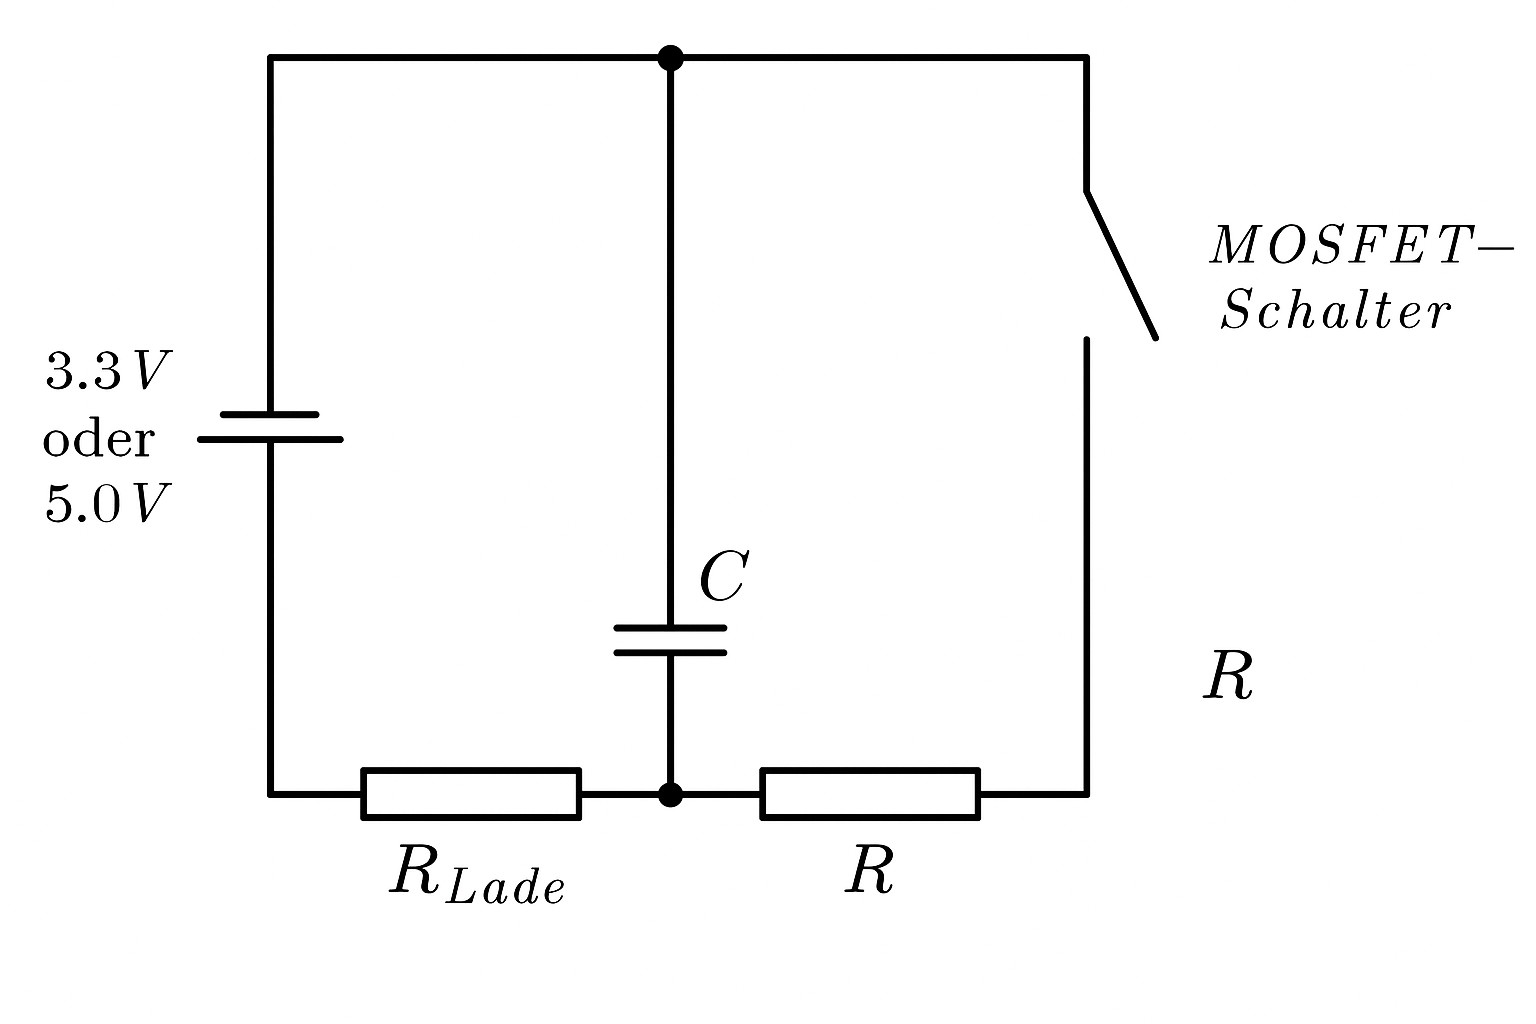

Der Widerstand $R_{lade}$ blieb dafür die ganze Zeit gleich und R wurde ausgetauscht. Genutzt haben wir dafür $R_{lade} = 986 \Omega$ und für $R$:
|Messung |R[$\Omega$]|
| ------------------------------------------- | --------------------------------------- |
| 1                            | 1,3                            | 
| 2                            | 10                              | 
| 3                           | 99,2                              | 
| 4                           | 217,3                               | 
| 5                            | 989                              | 

Für den Kondensator haben wir eine Kapazität von 229,9 nF gemessen. Der Arduino hat in der Schaltung in den gleichen Zeitabständen immer wieder den MOSFET-Schalter geschaltet und das Picoscope hat die Spannung über den Kondensator gemessen. Durch die immer gleichen Zeitabstände konnte das Programm "Picoscope 7" die Kurve mit richtig gewähltem Trigger gut anzeigen und die Werte dann exportiert werden.

## Messung RC-Kreis

Als erstes betrachten wir die Messungen unserer Entladung. Im folgenden sind für alle 5 Widerstände die Messwerte grafisch dargestellt. Da am Anfang noch länger das Spannungsmaximum $U_{Max}$ vorliegt und auch am Ende der Kondensator länger entladen ist, haben wir die wichtigen Daten ausgeschnitten und nur diese dargestellt um einen genaueren Verlauf der Entladung darzustellen.

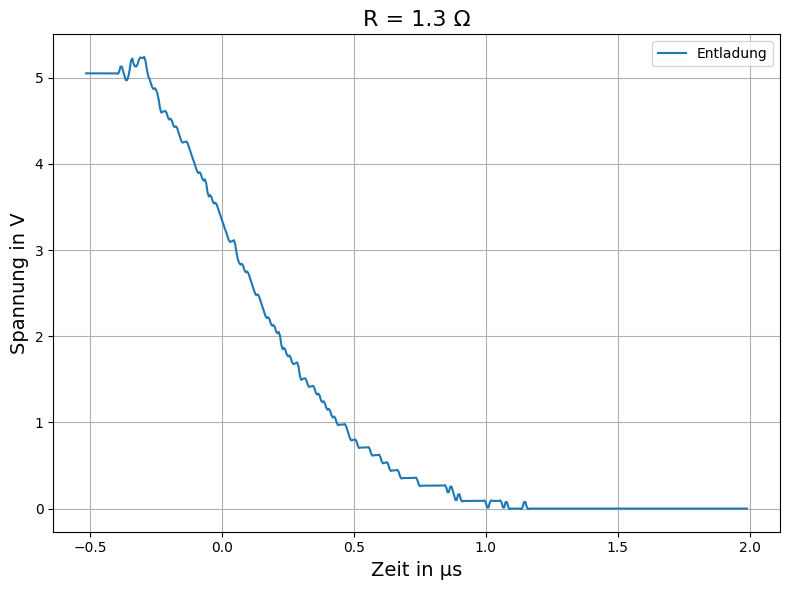

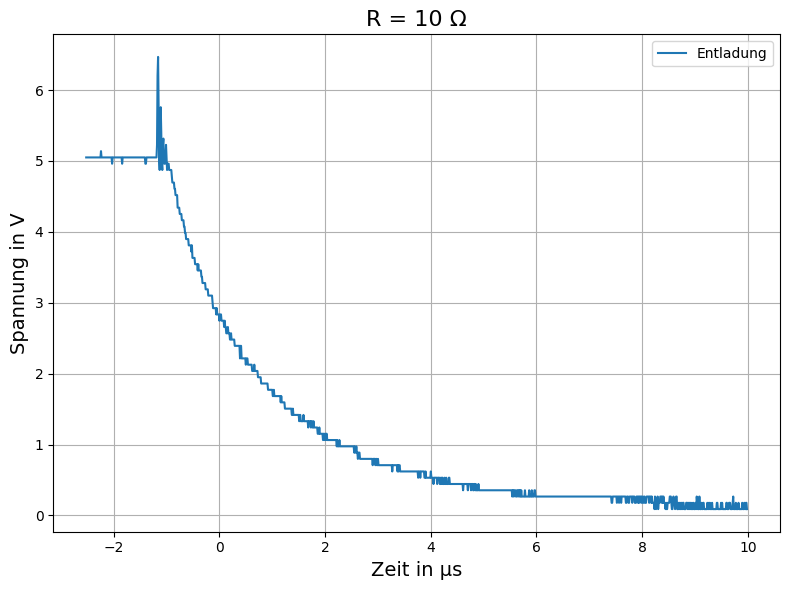

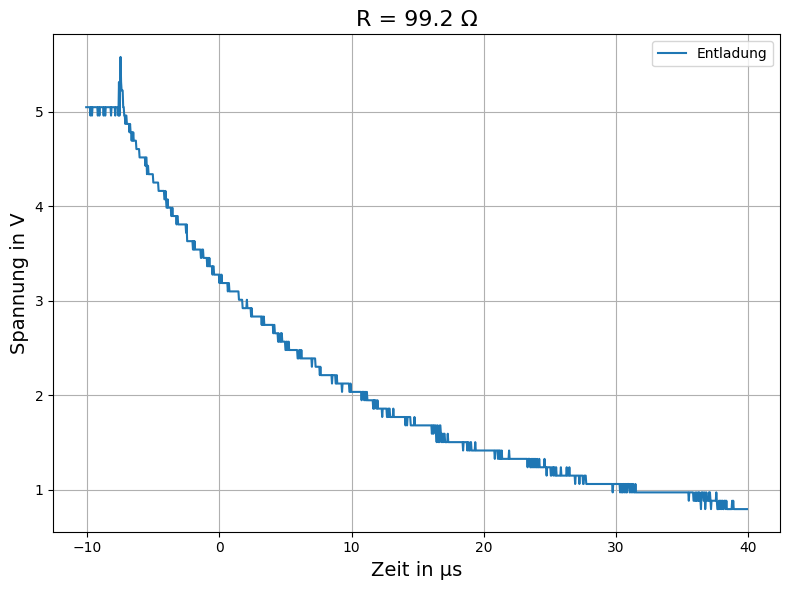

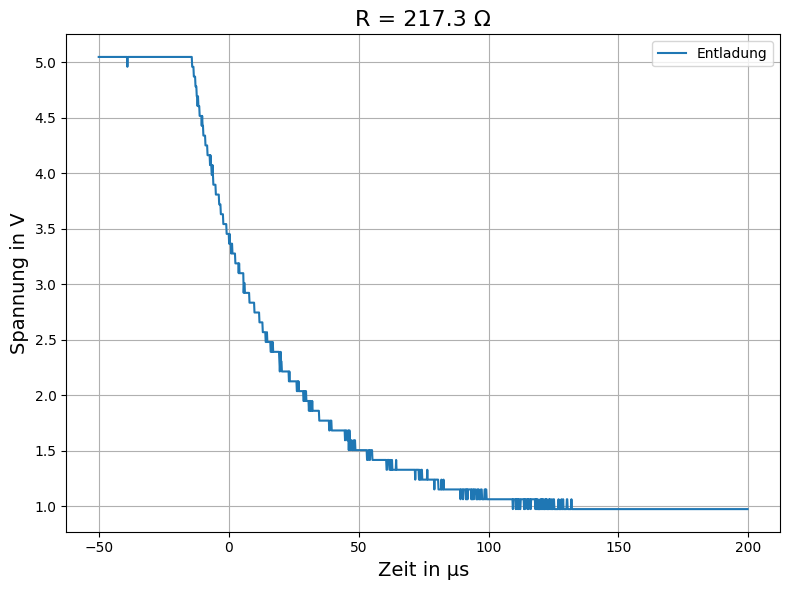

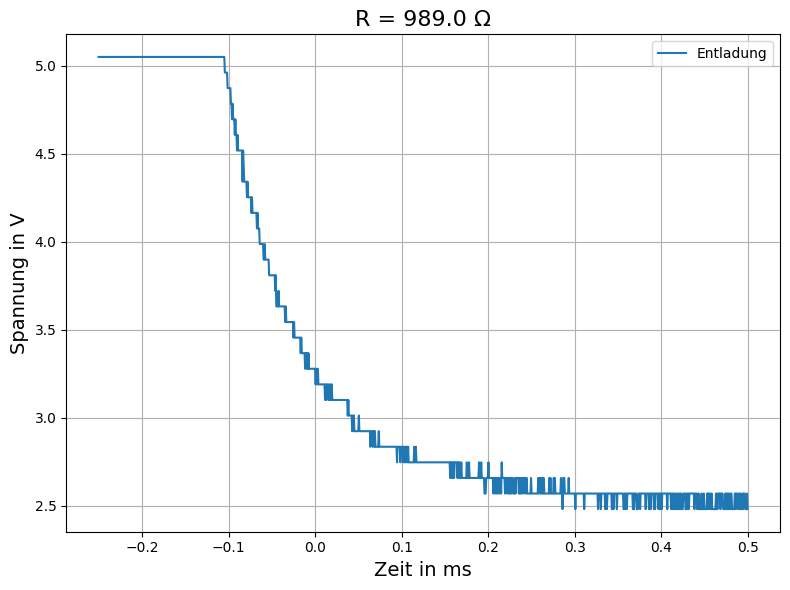

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Resistors = [1.3, 10, 99.2, 217.3, 989.0]  # in Ohms

df_R1 = pd.read_csv('Messwerte/Aufgabe1_1R.csv')
df_R10 = pd.read_csv('Messwerte/Aufgabe1_10R.csv')
df_R100 = pd.read_csv('Messwerte/Aufgabe1_100R.csv')
df_R220 = pd.read_csv('Messwerte/Aufgabe1_220R.csv')
df_R1000 = pd.read_csv('Messwerte/Aufgabe1_1000R.csv')

dataframes = [df_R1, df_R10, df_R100, df_R220, df_R1000]
for i in range(4):
    R = Resistors[i]
    df = dataframes[i]
    n = len(df)
    start_idx = int(n * 0.45)
    end_idx   = int(n * 0.7)
    df_mid = df.iloc[start_idx:end_idx]
    plt.figure(figsize=(8, 6))
    plt.title(f'R = {R} Ω', fontsize=16)
    plt.xlabel('Zeit in µs', fontsize=14)
    plt.ylabel('Spannung in V', fontsize=14)
    plt.grid(True)
    plt.plot(df_mid['Time'], df_mid['Channel A'], label='Entladung')
    plt.legend()
    plt.tight_layout()
    plt.show()




df = dataframes[4]
R = Resistors[4]
n = len(df)
start_idx = int(n * 0.45)
end_idx   = int(n * 0.6)
df_mid = df.iloc[start_idx:end_idx]
plt.figure(figsize=(8, 6))
plt.title(f'R = {R} Ω', fontsize=16)
plt.xlabel('Zeit in ms', fontsize=14)
plt.ylabel('Spannung in V', fontsize=14)
plt.grid(True)
plt.plot(df_mid['Time'], df_mid['Channel A'], label='Entladung')
plt.legend()
plt.tight_layout()
plt.show()


# Berechnung der Impendanz und Phasenverschiebung

Berechnung von Impedanz und Phasenverschiebung eines RC-Serienkreises

Um die Impedanz $Z$ und die Phasenverschiebung $\varphi$ eines RC-Serienkreises zu bestimmen, benötigt man zwei Schritte:

## Bestimmung der Zeitkonstante aus der Entladekurve

Wird ein Kondensator über einen Widerstand entladen, folgt die Spannung einer Exponentialfunktion:

$$U_C(t) = U_0 \cdot e^{-t/\tau}$$

Mit der Zeitkonstante

$$\tau = R \cdot C$$

Aus der gemessenen Entladekurve kann man $\tau$ durch eine Exponentialanpassung oder durch Logarithmieren bestimmen.
Da der Entladewiderstand $R$ bekannt ist, ergibt sich die Kapazität des Kondensators zu:

$$C = \frac{\tau}{R}$$

Diese Kapazität ist die Grundlage für die spätere Impedanzberechnung.

## Berechnung der Impedanz im Frequenzbereich

Für eine sinusförmige Anregung mit Kreisfrequenz $\omega = 2\pi f$ besitzt ein Kondensator die komplexe Impedanz

$$Z_C = \frac{1}{j\omega C} = -j\cdot \frac{1}{\omega C}$$

Ein Serien-RC-Kreis hat daher die Gesamtimpedanz

$$Z = R - j\cdot\frac{1}{\omega C}$$

Der Betrag der Impedanz lautet:

$$|Z| = \sqrt{R^2 + \left(\frac{1}{\omega C}\right)^2}$$

Die Phasenverschiebung zwischen Strom und Spannung ergibt sich aus dem Argument der komplexen Impedanz:

$$\varphi = -\arctan \left(\frac{1}{\omega R C}\right)$$

Das Minuszeichen zeigt, dass die Spannung am RC-Glied gegenüber dem Strom nacheilt (stromführend). Da wir die Kapazität von unserem Kondensator und die Werte aller Widerstände kennen, könnten wir $\tau$ auch theoretisch berechnen. Somit können wir vergleichen wie gut unsere quantitative Berechnung anhand der Daten funktioniert hat.

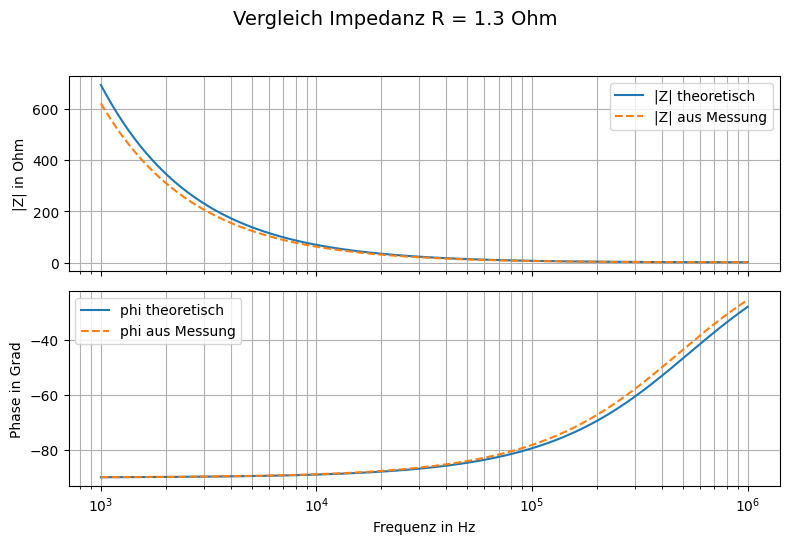

R = 1.3 Ohm
  tau_exp  = 3.336e-07 s
  C_exp    = 2.566e-07 F
  |Z|(f0)  theo = 68.709 Ohm,  Mess = 61.564 Ohm,  Abw = -10.40 %
  phi(f0)  theo = -88.92 Grad, Mess = -88.79 Grad, Abw_rel = -0.14 %



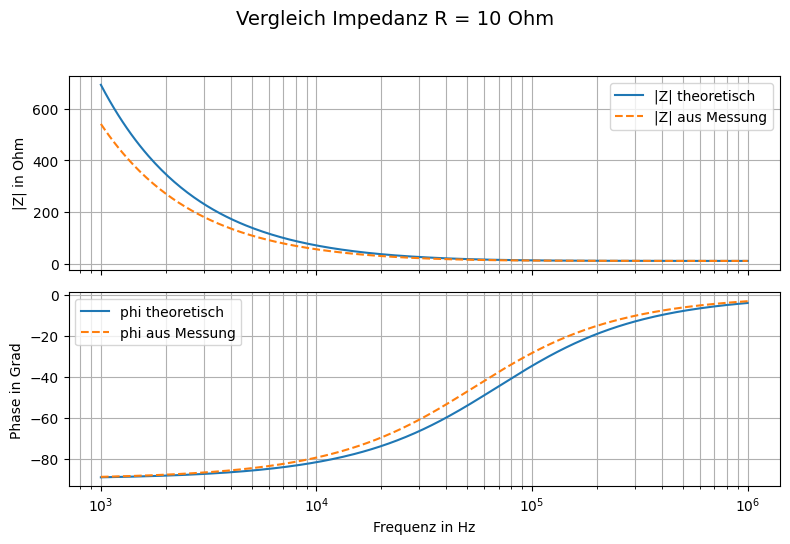

R = 10 Ohm
  tau_exp  = 2.943e-06 s
  C_exp    = 2.943e-07 F
  |Z|(f0)  theo = 69.421 Ohm,  Mess = 54.584 Ohm,  Abw = -21.37 %
  phi(f0)  theo = -81.72 Grad, Mess = -79.44 Grad, Abw_rel = -2.78 %



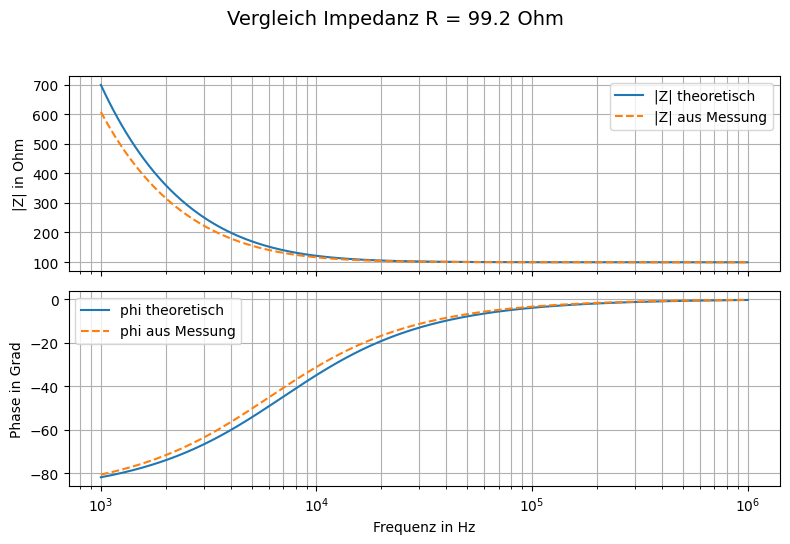

R = 99.2 Ohm
  tau_exp  = 2.632e-05 s
  C_exp    = 2.653e-07 F
  |Z|(f0)  theo = 120.664 Ohm,  Mess = 115.688 Ohm,  Abw = -4.12 %
  phi(f0)  theo = -34.70 Grad, Mess = -30.97 Grad, Abw_rel = -10.77 %



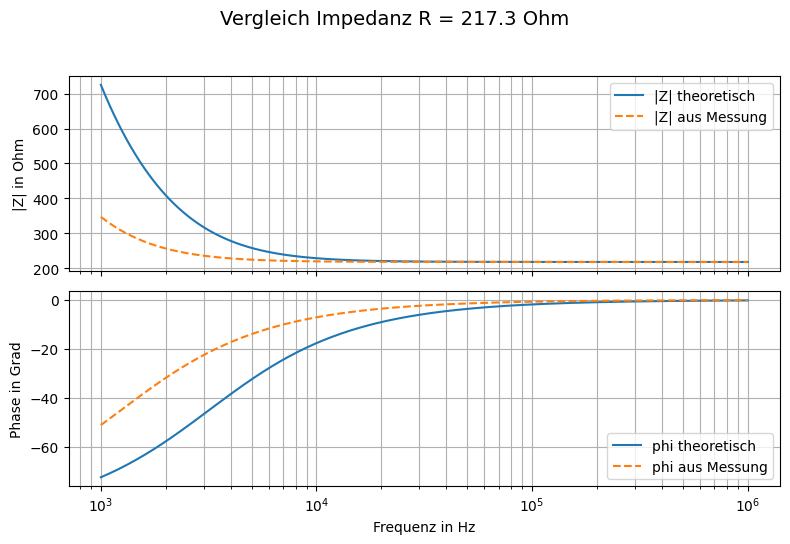

R = 217.3 Ohm
  tau_exp  = 1.279e-04 s
  C_exp    = 5.887e-07 F
  |Z|(f0)  theo = 227.900 Ohm,  Mess = 218.950 Ohm,  Abw = -3.93 %
  phi(f0)  theo = -17.54 Grad, Mess = -7.04 Grad, Abw_rel = -59.88 %



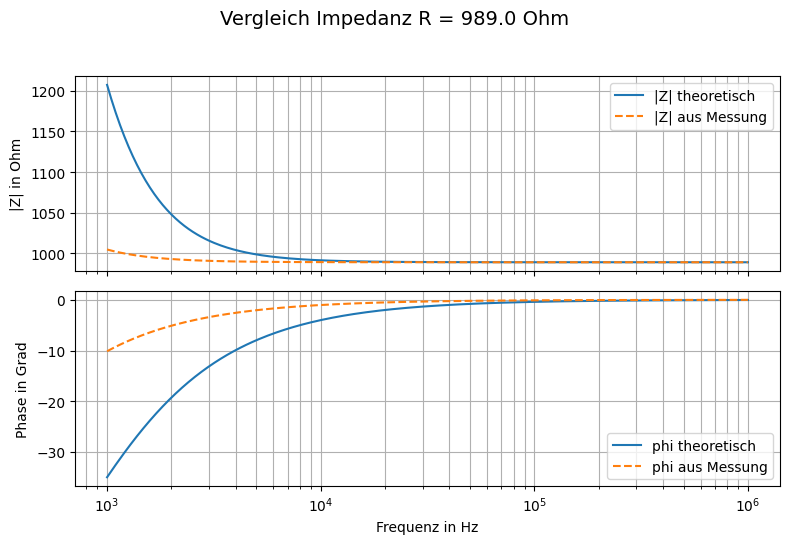

R = 989.0 Ohm
  tau_exp  = 8.896e-04 s
  C_exp    = 8.995e-07 F
  |Z|(f0)  theo = 991.383 Ohm,  Mess = 989.156 Ohm,  Abw = -0.22 %
  phi(f0)  theo = -3.97 Grad, Mess = -1.02 Grad, Abw_rel = -74.40 %



In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Entladewiderstände in Ohm
Resistors = [1.3, 10, 99.2, 217.3, 989.0]

# Theoretischer Kondensatorwert
C_theo = 229.9e-9  # 229,9 nF

# Dateien einlesen
df_R1    = pd.read_csv('Messwerte/Aufgabe1_1R.csv')
df_R10   = pd.read_csv('Messwerte/Aufgabe1_10R.csv')
df_R100  = pd.read_csv('Messwerte/Aufgabe1_100R.csv')
df_R220  = pd.read_csv('Messwerte/Aufgabe1_220R.csv')
df_R1000 = pd.read_csv('Messwerte/Aufgabe1_1000R.csv')

dataframes = [df_R1, df_R10, df_R100, df_R220, df_R1000]

# Ausschnittsbereiche wie bei dir
windows = [
    (0.45, 0.70),  # R = 1.3 Ohm
    (0.45, 0.70),  # R = 10 Ohm
    (0.45, 0.70),  # R = 99.2 Ohm
    (0.45, 0.70),  # R = 217.3 Ohm
    (0.45, 0.60)   # R = 989 Ohm
]

# Zeiteinheiten: erste vier Dateien in µs, letzte in ms (falls anders bitte anpassen)
time_scales = [1e-6, 1e-6, 1e-6, 1e-6, 1e-3]

def fit_tau(time_s, voltage):
    """Bestimmt tau und U0 aus U(t) = U0 * exp(-t/tau)."""
    t = np.asarray(time_s) - time_s.iloc[0]
    v = np.asarray(voltage)

    mask = v > 0
    t = t[mask]
    v = v[mask]

    ln_v = np.log(v)
    a, b = np.polyfit(t, ln_v, 1)  # ln v = a*t + b

    tau = -1.0 / a
    U0 = np.exp(b)
    return tau, U0

def impedance_RC_series(R, C, f):
    """Komplexe Impedanz Z eines Serien-RC-Kreises bei Frequenz f (Hz)."""
    omega = 2 * np.pi * f
    return R - 1j / (omega * C)

# Frequenzachse fuer die Bode-Plots
frequencies = np.logspace(3, 6, 300)  # 1 kHz ... 1 MHz
f0 = 1e4                               # Referenzfrequenz fuer numerische Abweichungen (10 kHz)

# Schleife ueber alle Widerstaende
for i, (df, R) in enumerate(zip(dataframes, Resistors)):
    n = len(df)
    start_frac, end_frac = windows[i]
    start_idx = int(n * start_frac)
    end_idx   = int(n * end_frac)
    df_mid = df.iloc[start_idx:end_idx]

    # Zeit in Sekunden
    time_s = df_mid['Time'] * time_scales[i]
    voltage = df_mid['Channel A']

    # Aus Entladungskurve tau und C_exp bestimmen
    tau_exp, U0 = fit_tau(time_s, voltage)
    C_exp = tau_exp / R

    # Impedanzen berechnen
    Z_theo = impedance_RC_series(R, C_theo, frequencies)
    Z_exp  = impedance_RC_series(R, C_exp,  frequencies)

    Zabs_theo = np.abs(Z_theo)
    Zabs_exp  = np.abs(Z_exp)
    phi_theo  = np.degrees(np.angle(Z_theo))
    phi_exp   = np.degrees(np.angle(Z_exp))

    # Werte bei f0 fuer die Textausgabe
    idx0 = np.argmin(np.abs(frequencies - f0))
    Z0_theo = Zabs_theo[idx0]
    Z0_exp  = Zabs_exp[idx0]
    phi0_theo = phi_theo[idx0]
    phi0_exp  = phi_exp[idx0]

    err_Z0   = (Z0_exp  - Z0_theo)  / Z0_theo  * 100.0
    err_phi0 = (phi0_exp - phi0_theo) / (phi0_theo if phi0_theo != 0 else 1) * 100.0

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    fig.suptitle(f'Vergleich Impedanz R = {R} Ohm', fontsize=14)

    # Betrag
    ax1.semilogx(frequencies, Zabs_theo, label='|Z| theoretisch')
    ax1.semilogx(frequencies, Zabs_exp, '--', label='|Z| aus Messung')
    ax1.set_ylabel('|Z| in Ohm')
    ax1.grid(True, which='both')
    ax1.legend()

    # Phase
    ax2.semilogx(frequencies, phi_theo, label='phi theoretisch')
    ax2.semilogx(frequencies, phi_exp, '--', label='phi aus Messung')
    ax2.set_xlabel('Frequenz in Hz')
    ax2.set_ylabel('Phase in Grad')
    ax2.grid(True, which='both')
    ax2.legend()

    # # Erklaer-Text unter dem Plot
    # text = (
    #     "Impedanz eines Serien-RC-Kreises: Z = R - j/(omega * C)\n"
    #     "Betrag: |Z| = sqrt(R^2 + (1/(omega*C))^2), Phase: phi = -arctan(1/(omega*R*C)).\n"
    #     "C_theo = {:.3e} F, C_aus_Messung = {:.3e} F (tau = R * C aus Entladekurve).\n"
    #     "Bei f = {:.0f} Hz: |Z|_theo = {:.3f} Ohm, |Z|_Mess = {:.3f} Ohm, Abweichung = {:+.2f} %.\n"
    #     "phi_theo = {:.2f} Grad, phi_Mess = {:.2f} Grad, relative Abweichung = {:+.2f} %."
    # ).format(C_theo, C_exp, f0, Z0_theo, Z0_exp, err_Z0,
    #          phi0_theo, phi0_exp, err_phi0)

    # # fig.text(x, y, ...) - y etwas unterhalb der x-Achse des zweiten Subplots
    # fig.text(0.02, 0.01, text, fontsize=8, va='bottom')

    plt.tight_layout(rect=[0, 0.08, 1, 0.95])  # Platz fuer den Text unten und Titel oben lassen
    plt.show()

    # Optional auch in der Konsole kurz ausgeben
    print(f"R = {R} Ohm")
    print(f"  tau_exp  = {tau_exp:.3e} s")
    print(f"  C_exp    = {C_exp:.3e} F")
    print(f"  |Z|(f0)  theo = {Z0_theo:.3f} Ohm,  Mess = {Z0_exp:.3f} Ohm,  Abw = {err_Z0:+.2f} %")
    print(f"  phi(f0)  theo = {phi0_theo:.2f} Grad, Mess = {phi0_exp:.2f} Grad, Abw_rel = {err_phi0:+.2f} %")
    print()
